<a href="https://colab.research.google.com/github/Ishany0/PM2.5_AirQuality/blob/main/mlp_from_scratch_on_pm2_5_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

***Preprocessing***

In [2]:
PSRA_data = pd.read_csv('/content/PRSA_data_2010.1.1-2014.12.31.csv')
df = pd.DataFrame(PSRA_data)

df = df.dropna()
encoded_df = pd.get_dummies(df , columns = ['cbwd'] , drop_first = True)

In [3]:
feature_cols = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'month', 'hour'] + \
               [c for c in encoded_df.columns if c.startswith('cbwd_')]

X = encoded_df[feature_cols].values.astype(float)
Y = encoded_df['pm2.5'].values.reshape(-1, 1).astype(float)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

***Model***

In [19]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.randn(input_size, hidden_size)
        self.weights_hidden_output = np.random.randn(hidden_size, output_size)
        self.bias_hidden = np.zeros((1, hidden_size))
        self.bias_output = np.zeros((1, output_size))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def forward(self, X):
        self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = self.relu(self.hidden_input)
        self.final_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        self.final_output = self.final_input
        return self.final_output

    def backward(self, X, y, output, learning_rate):
        m = X.shape[0]
        output_error = (output - y) * (2 / m)
        hidden_error = np.dot(output_error, self.weights_hidden_output.T) * self.relu_derivative(self.hidden_input)

        self.weights_hidden_output -= learning_rate * np.dot(self.hidden_output.T, output_error)
        self.bias_output -= learning_rate * np.sum(output_error, axis=0, keepdims=True)
        self.weights_input_hidden -= learning_rate * np.dot(X.T, hidden_error)
        self.bias_hidden -= learning_rate * np.sum(hidden_error, axis=0, keepdims=True)

    def train(self, X, y, X_val, y_val, epochs, learning_rate):
        train_losses, val_losses = [], []
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output, learning_rate)
            train_loss = np.mean((output - y) ** 2)

            val_output = self.forward(X_val)
            val_loss = np.mean((val_output - y_val) ** 2)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if (epoch + 1) % 100 == 0:
                print(f'Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
        return train_losses, val_losses

    def predict(self, X):
        return self.forward(X)

***Training***

In [20]:
Y_train_arr = Y_train.reshape(-1, 1)
Y_test_arr = Y_test.reshape(-1, 1)

In [28]:
mlp = MLP(input_size=X_train.shape[1], hidden_size=32, output_size=1)
train_losses, val_losses = mlp.train(X_train, Y_train_arr, X_test, Y_test_arr, epochs=2000, learning_rate=0.001)

Epoch 100 | Train Loss: 5665.9954 | Val Loss: 6070.2895
Epoch 200 | Train Loss: 5193.1868 | Val Loss: 5585.4433
Epoch 300 | Train Loss: 4895.0451 | Val Loss: 5296.0064
Epoch 400 | Train Loss: 4725.5711 | Val Loss: 5132.1438
Epoch 500 | Train Loss: 4612.7313 | Val Loss: 5021.4591
Epoch 600 | Train Loss: 4525.9425 | Val Loss: 4935.7726
Epoch 700 | Train Loss: 4461.5984 | Val Loss: 4875.7540
Epoch 800 | Train Loss: 4414.9578 | Val Loss: 4832.6157
Epoch 900 | Train Loss: 4377.6030 | Val Loss: 4799.7663
Epoch 1000 | Train Loss: 4345.7715 | Val Loss: 4771.5457
Epoch 1100 | Train Loss: 4314.5337 | Val Loss: 4745.1107
Epoch 1200 | Train Loss: 4282.9082 | Val Loss: 4715.8713
Epoch 1300 | Train Loss: 4255.7154 | Val Loss: 4689.8455
Epoch 1400 | Train Loss: 4232.7589 | Val Loss: 4666.6290
Epoch 1500 | Train Loss: 4210.9537 | Val Loss: 4646.4041
Epoch 1600 | Train Loss: 4192.2682 | Val Loss: 4631.2820
Epoch 1700 | Train Loss: 4174.5961 | Val Loss: 4615.2406
Epoch 1800 | Train Loss: 4159.1933 | Val

***Prediction***

In [29]:
example_idx = 0
example_X = X_test[example_idx:example_idx+1]
example_actual = Y_test_arr[example_idx][0]

example_pred = mlp.predict(example_X)[0][0]

print(f"Actual pm2.5:    {example_actual:.2f}")
print(f"Predicted pm2.5: {example_pred:.2f}")
print(f"Error:           {abs(example_actual - example_pred):.2f}")

Actual pm2.5:    215.00
Predicted pm2.5: 228.02
Error:           13.02


***Plotting***


Train R²: 0.5071 | Test R²: 0.4804
Train RMSE: 64.3007 | Test RMSE: 67.6619


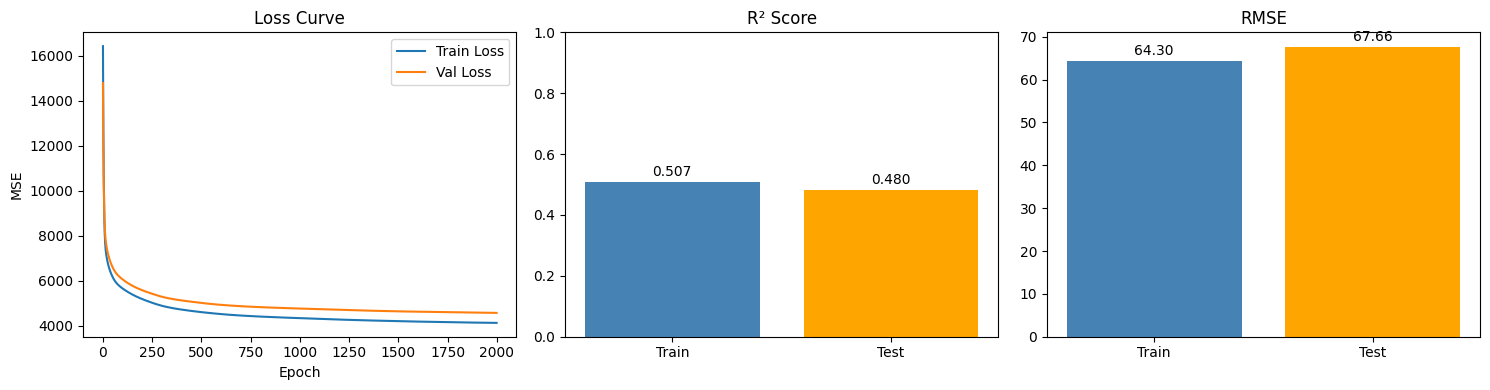

In [30]:
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

train_r2 = r2_score(Y_train_arr, y_train_pred)
test_r2 = r2_score(Y_test_arr, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(Y_train_arr, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(Y_test_arr, y_test_pred))

print(f"\nTrain R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Loss Curve')
axes[0].legend()


axes[1].bar(['Train', 'Test'], [train_r2, test_r2], color=['steelblue', 'orange'])
axes[1].set_title('R² Score')
axes[1].set_ylim(0, 1)
for i, v in enumerate([train_r2, test_r2]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha='center')

axes[2].bar(['Train', 'Test'], [train_rmse, test_rmse], color=['steelblue', 'orange'])
axes[2].set_title('RMSE')
for i, v in enumerate([train_rmse, test_rmse]):
    axes[2].text(i, v + max(train_rmse, test_rmse) * 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()